In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
stats_1 = pd.read_csv("all_stats_vs_revenue_1.csv")
stats_2 = pd.read_csv("all_stats_vs_revenue_2.csv")


In [63]:
import pandas as pd
import numpy as np

# 读取两个CSV文件
stats_1 = pd.read_csv("all_stats_vs_revenue_1.csv")
stats_2 = pd.read_csv("all_stats_vs_revenue_2.csv")

print(f"stats_1 shape: {stats_1.shape}")
print(f"stats_2 shape: {stats_2.shape}")

# 找到重叠的起始点
# 方法1: 比较stats_2的第一行与stats_1中的所有行
def find_overlap_point(df1, df2, tolerance=1e-6):
    """
    找到df2的第一行在df1中的位置
    """
    first_row_df2 = df2.iloc[0]
    
    # 获取数值列进行比较
    numeric_cols = df1.select_dtypes(include=[np.number]).columns
    
    for i in range(len(df1)):
        # 比较数值列
        match = True
        for col in numeric_cols:
            if col in first_row_df2.index:
                if abs(df1.iloc[i][col] - first_row_df2[col]) > tolerance:
                    match = False
                    break
        
        if match:
            return i
    
    return None

# 查找重叠点
overlap_index = find_overlap_point(stats_1, stats_2)

if overlap_index is not None:
    print(f"找到重叠点在 stats_1 的索引: {overlap_index}")
    
    # 方法1: 直接拼接（从重叠点开始用stats_2替换）
    stats_combined_method1 = pd.concat([
        stats_1.iloc[:overlap_index],  # stats_1的前半部分（不包括重叠行）
        stats_2                        # 完整的stats_2
    ], ignore_index=True)
    
    print(f"方法1 - 合并后形状: {stats_combined_method1.shape}")
    
    # 方法2: 更保守的拼接（只添加stats_2中不重叠的部分）
    # 计算stats_1和stats_2的重叠长度
    overlap_length = len(stats_1) - overlap_index
    
    if overlap_length <= len(stats_2):
        # stats_2完全包含重叠部分，添加stats_2中超出的部分
        stats_combined_method2 = pd.concat([
            stats_1,                                    # 完整的stats_1
            stats_2.iloc[overlap_length:]              # stats_2中超出重叠的部分
        ], ignore_index=True)
    else:
        # 重叠部分超过了stats_2的长度
        stats_combined_method2 = stats_1  # 保持stats_1不变
    
    print(f"方法2 - 合并后形状: {stats_combined_method2.shape}")
    
    # 验证拼接结果
    print("\n=== 拼接验证 ===")
    print("重叠点附近的数据对比:")
    print("stats_1 重叠行:")
    print(stats_1.iloc[overlap_index:overlap_index+2])
    print("\nstats_2 开始行:")
    print(stats_2.iloc[:2])
    
    # 选择使用哪种方法
    stats = stats_combined_method1  # 通常使用方法1
    
else:
    print("未找到重叠点，尝试其他方法...")
    
    # 如果直接比较失败，尝试比较特定列
    # 假设有时间戳或唯一标识列
    if 'Unnamed: 0' in stats_1.columns and 'Unnamed: 0' in stats_2.columns:
        # 使用索引列查找重叠
        last_index_1 = stats_1['Unnamed: 0'].iloc[-1]
        first_index_2 = stats_2['Unnamed: 0'].iloc[0]
        
        if first_index_2 <= last_index_1:
            # 有重叠，找到具体位置
            overlap_mask = stats_1['Unnamed: 0'] >= first_index_2
            overlap_start = stats_1[overlap_mask].index[0]
            
            stats = pd.concat([
                stats_1.iloc[:overlap_start],
                stats_2
            ], ignore_index=True)
            
            print(f"基于索引列找到重叠，合并后形状: {stats.shape}")
        else:
            # 无重叠，直接拼接
            stats = pd.concat([stats_1, stats_2], ignore_index=True)
            print(f"无重叠，直接拼接，合并后形状: {stats.shape}")
    else:
        # 最后的备选方案：直接拼接
        stats = pd.concat([stats_1, stats_2], ignore_index=True)
        print(f"直接拼接，合并后形状: {stats.shape}")

# 清理合并后的数据
if 'Unnamed: 0' in stats.columns:
    stats = stats.drop('Unnamed: 0', axis=1)

# 重置索引
stats = stats.reset_index(drop=True)

print(f"\n最终合并数据形状: {stats.shape}")
print("\n合并后数据预览:")
print(stats.head())
print("\n...")
print(stats.tail())

# 检查数据完整性
print(f"\n=== 数据完整性检查 ===")
print(f"总行数: {len(stats)}")
print(f"缺失值统计:")
print(stats.isnull().sum())

# 如果有revenues列，显示基本统计
if 'revenues' in stats.columns:
    print(f"\nrevenues列统计:")
    print(f"  总收益: {stats['revenues'].sum():.6f}")
    print(f"  平均收益: {stats['revenues'].mean():.6f}")
    print(f"  收益标准差: {stats['revenues'].std():.6f}")

stats_1 shape: (639402, 11)
stats_2 shape: (539402, 11)
找到重叠点在 stats_1 的索引: 600000
方法1 - 合并后形状: (1139402, 11)
方法2 - 合并后形状: (1139402, 11)

=== 拼接验证 ===
重叠点附近的数据对比:
stats_1 重叠行:
             stats_1    stats_2   stats_3       stats_4   stats_5   stats_6  \
600000 -12342.934756  31.313333  1.578768  1.257097e+06  0.725538  0.068050   
600001 -11956.163048  31.314788  1.618036  1.257309e+06  0.725171  0.068916   

         stats_7   stats_8   stats_9      stats_10   revenues  
600000  0.764772  0.197049  4.251905  19651.132387  23.425274  
600001  0.764355  0.907361  4.217713  18241.623105  24.263157  

stats_2 开始行:
        stats_1    stats_2   stats_3       stats_4   stats_5   stats_6  \
0 -12342.934756  31.313333  1.578768  1.257097e+06  0.725538  0.068050   
1 -11956.163048  31.314788  1.618036  1.257309e+06  0.725171  0.068916   

    stats_7   stats_8   stats_9      stats_10   revenues  
0  0.764772  0.197049  4.251905  19651.132387  23.425274  
1  0.764355  0.907361  4.217713  18241.

In [64]:
stats

,stats_1,stats_2,stats_3,stats_4,stats_5,stats_6,stats_7,stats_8,stats_9,stats_10,revenues
0,-9659.436314,31.676654,4.179952,2.619471e+05,0.389767,0.119052,0.371009,-0.193642,4.634380,999236.720395,-2.538876
1,-10378.355503,31.686585,3.918506,2.610480e+05,0.389313,0.116785,0.370563,-0.625243,4.788858,983806.187187,-2.464805
2,-10101.836670,31.685810,3.889684,2.503120e+05,0.389580,0.114377,0.366220,-1.190992,4.441716,979684.067891,-0.753223
3,-10266.991472,31.681937,3.867600,2.504345e+05,0.390389,0.114029,0.366999,-2.017358,4.576838,979684.067891,-6.160408
4,-13014.091036,31.683914,3.853636,2.502650e+05,0.389982,0.113044,0.366815,-2.710301,4.679182,976125.912120,-5.418989
...,...,...,...,...,...,...,...,...,...,...,...
1139397,-10055.837126,30.787170,5.505391,2.922346e+06,0.716094,0.121548,0.779013,-0.070080,4.194409,227016.403051,-7.835400
1139398,-9801.852115,30.795945,5.192169,2.909048e+06,0.713145,0.115511,0.777319,0.349706,4.138160,227016.403078,-2.945540
1139399,-9852.879440,30.793262,4.957420,2.897974e+06,0.708851,0.107492,0.773911,1.081485,4.117222,227016.403051,-2.921117
1139400,-10606.878574,30.790334,4.820600,2.896043e+06,0.707637,0.104548,0.774039,0.904541,4.214835,227016.403047,-7.614233


In [65]:
# all_path = None

# for coin in coins.columns:
#     if coin == 'Unnamed: 0':
#         continue
#     coin_revs = np.array(coins[coin].dropna())
#     coin_path = coin_revs.cumsum()
#     if all_path is None:
#         all_path = coin_path
#     else:
#         all_path = all_path + coin_path

#     plt.plot(coin_path, label=coin)
#     plt.title(f"Cumulative Revenue Path for {coin}")
#     plt.xlabel("Time")
#     plt.ylabel("Cumulative Revenue")
#     plt.legend()
#     plt.show()
#     plt.close()
  
# plt.plot(all_path, label="Aggregate Revenue Path", color='red', linewidth=2)
# plt.title("Aggregate Cumulative Revenue Path for All Coins")
# plt.xlabel("Time")
# plt.ylabel("Cumulative Revenue")
# plt.legend()
# plt.show()
# plt.close()

In [66]:
stats.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues'],
      dtype='object')

=== Filtering Analysis ===
Total entries: 1139402
Qualifying entries: 14691
Filtering rate: 1.29%
Original total revenue: 222528.159584
Filtered total revenue: 11287.187544
Revenue retention: 5.07%


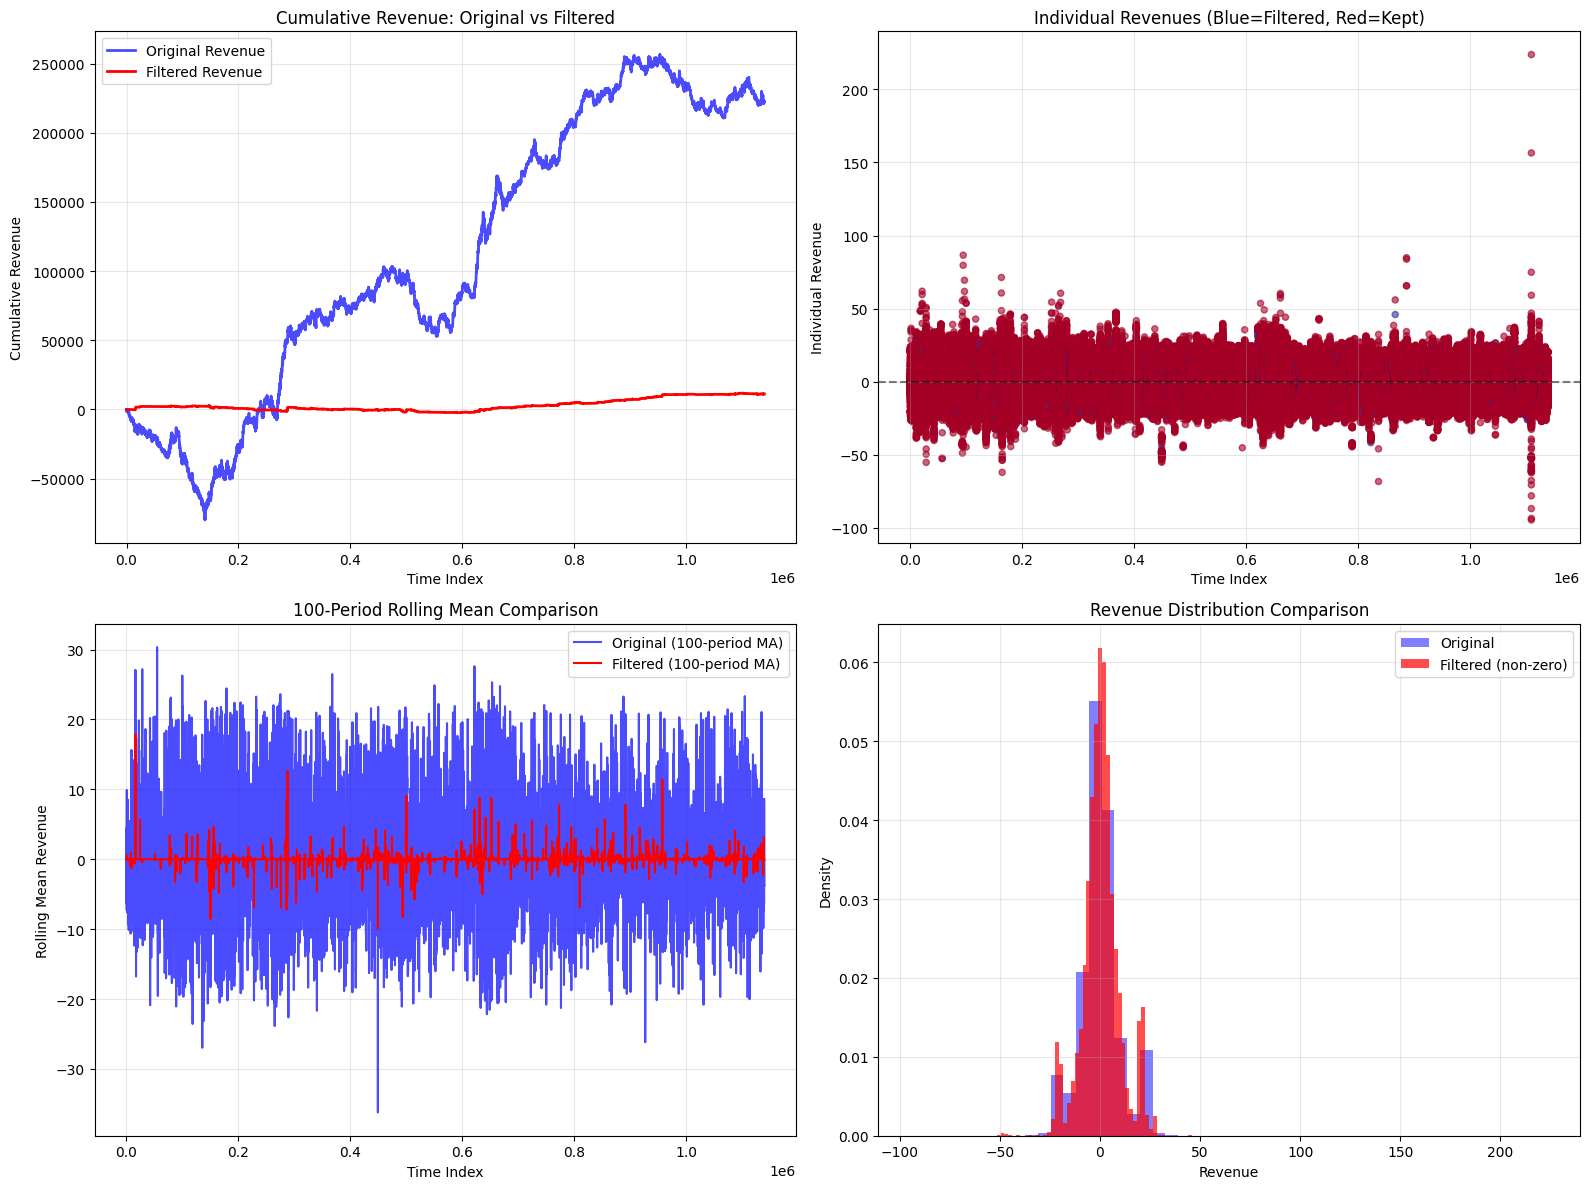


=== Performance Metrics ===
Original Revenue Stats:
  Mean: 0.195303
  Std:  9.632859
  Sharpe: 0.0203
  Win Rate: 48.88%

Filtered Revenue Stats (non-zero only):
  Mean: 0.768306
  Std:  9.589657
  Sharpe: 0.0801
  Win Rate: 53.71%

Filtered Revenue Stats (including zeros):
  Mean: 0.009906
  Std:  1.092314
  Sharpe: 0.0091
  Win Rate: 0.69%

=== Time-based Analysis ===
Chunk size: 100
Number of chunks: 11395
Original chunk mean: 19.528579
Filtered chunk mean: 0.990539


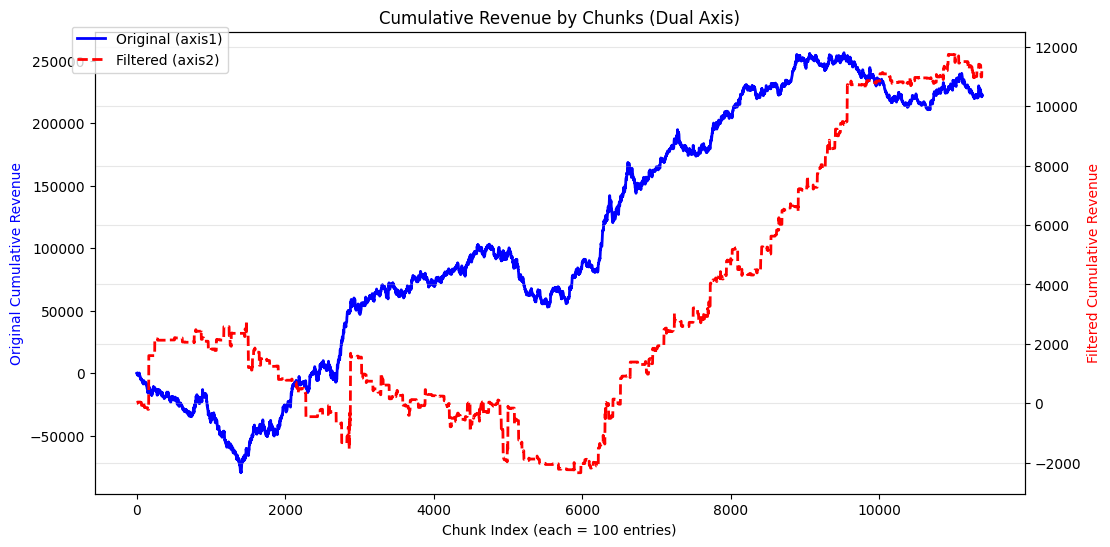


=== Filter Condition Analysis ===
Individual condition pass rates:
  stats_6 > 0.1:     12.15%
  stats_5 > 0.6:     52.29%
  stats_9 < 6:       83.00%
  stats_1 < -7500:   91.09%
  |stats_8| < 10:    85.97%
  All conditions:    1.29%


In [67]:
# if res.success and corr_2_mean>0.1 and corr_1_mean>0.6 and cmi_std<6 and objective_value < -7500  and abs(cmi_mean)<10:

# stats_1.append(objective_value)
# stats_2.append(coef_1_mean)
# stats_3.append(coef_2_mean)
# stats_4.append(coef_3_mean)
# stats_5.append(corr_1_mean)
# stats_6.append(corr_2_mean)
# stats_7.append(corr_3_mean)
# stats_8.append(cmi_mean)
# stats_9.append(cmi_std)
# stats_10.append(amihud_mean)

# Create filtered revenue series with 0s for non-qualifying entries
filtered_revenues = stats['revenues'].copy()

# Set revenues to 0 where conditions are not met
condition_mask = (
    (stats['stats_6'] > 0.1) &
    (stats['stats_5'] > 0.6) &
    (stats['stats_9'] < 6) &
    (stats['stats_1'] < -10000) &
    (stats['stats_8'].abs() < 10) & 
    (stats['stats_8'].abs() > 5) 
)

# Where condition is False, set revenue to 0
filtered_revenues[~condition_mask] = 0

# Calculate cumulative sum
cumulative_filtered = filtered_revenues.cumsum()
cumulative_original = stats['revenues'].cumsum()

# Print statistics
print("=== Filtering Analysis ===")
print(f"Total entries: {len(stats)}")
print(f"Qualifying entries: {condition_mask.sum()}")
print(f"Filtering rate: {condition_mask.sum() / len(stats):.2%}")
print(f"Original total revenue: {stats['revenues'].sum():.6f}")
print(f"Filtered total revenue: {filtered_revenues.sum():.6f}")
print(f"Revenue retention: {filtered_revenues.sum() / stats['revenues'].sum():.2%}")

# Create comprehensive plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative revenue comparison
axes[0, 0].plot(cumulative_original.index, cumulative_original.values, 
                label='Original Revenue', color='blue', alpha=0.7, linewidth=2)
axes[0, 0].plot(cumulative_filtered.index, cumulative_filtered.values, 
                label='Filtered Revenue', color='red', linewidth=2)
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Cumulative Revenue')
axes[0, 0].set_title('Cumulative Revenue: Original vs Filtered')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Individual revenues with filtering
axes[0, 1].scatter(range(len(stats)), stats['revenues'], 
                   c=condition_mask, cmap='RdYlBu', alpha=0.6, s=20)
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Individual Revenue')
axes[0, 1].set_title('Individual Revenues (Blue=Filtered, Red=Kept)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Rolling statistics
window = 100
rolling_original = stats['revenues'].rolling(window).mean()
rolling_filtered = filtered_revenues.rolling(window).mean()

axes[1, 0].plot(rolling_original.index, rolling_original.values, 
                label=f'Original ({window}-period MA)', color='blue', alpha=0.7)
axes[1, 0].plot(rolling_filtered.index, rolling_filtered.values, 
                label=f'Filtered ({window}-period MA)', color='red')
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Rolling Mean Revenue')
axes[1, 0].set_title(f'{window}-Period Rolling Mean Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram comparison
axes[1, 1].hist(stats['revenues'], bins=50, alpha=0.5, label='Original', 
                color='blue', density=True)
axes[1, 1].hist(filtered_revenues[filtered_revenues != 0], bins=50, alpha=0.7, 
                label='Filtered (non-zero)', color='red', density=True)
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Revenue Distribution Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed performance analysis
print("\n=== Performance Metrics ===")
print(f"Original Revenue Stats:")
print(f"  Mean: {stats['revenues'].mean():.6f}")
print(f"  Std:  {stats['revenues'].std():.6f}")
print(f"  Sharpe: {stats['revenues'].mean() / stats['revenues'].std():.4f}")
print(f"  Win Rate: {(stats['revenues'] > 0).mean():.2%}")

print(f"\nFiltered Revenue Stats (non-zero only):")
non_zero_filtered = filtered_revenues[filtered_revenues != 0]
if len(non_zero_filtered) > 0:
    print(f"  Mean: {non_zero_filtered.mean():.6f}")
    print(f"  Std:  {non_zero_filtered.std():.6f}")
    print(f"  Sharpe: {non_zero_filtered.mean() / non_zero_filtered.std():.4f}")
    print(f"  Win Rate: {(non_zero_filtered > 0).mean():.2%}")
else:
    print("  No qualifying entries!")

print(f"\nFiltered Revenue Stats (including zeros):")
print(f"  Mean: {filtered_revenues.mean():.6f}")
print(f"  Std:  {filtered_revenues.std():.6f}")
print(f"  Sharpe: {filtered_revenues.mean() / filtered_revenues.std():.4f}")
print(f"  Win Rate: {(filtered_revenues > 0).mean():.2%}")

# Monthly/yearly analysis if applicable
print(f"\n=== Time-based Analysis ===")
chunk_size = 100  # Adjust based on your data frequency

chunks_original = [stats['revenues'].iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(stats), chunk_size)]
chunks_filtered = [filtered_revenues.iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(filtered_revenues), chunk_size)]

print(f"Chunk size: {chunk_size}")
print(f"Number of chunks: {len(chunks_original)}")
print(f"Original chunk mean: {np.mean(chunks_original):.6f}")
print(f"Filtered chunk mean: {np.mean(chunks_filtered):.6f}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
chunk_indices = range(len(chunks_original))
ax1.plot(chunk_indices, np.cumsum(chunks_original), 'b-', label='Original (axis1)', linewidth=2)
ax2.plot(chunk_indices, np.cumsum(chunks_filtered), 'r--', label='Filtered (axis2)', linewidth=2)
ax1.set_xlabel(f'Chunk Index (each = {chunk_size} entries)')
ax1.set_ylabel('Original Cumulative Revenue', color='b')
ax2.set_ylabel('Filtered Cumulative Revenue', color='r')
plt.title('Cumulative Revenue by Chunks (Dual Axis)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(True, alpha=0.3)
plt.show()

# Filter condition analysis
print(f"\n=== Filter Condition Analysis ===")
print("Individual condition pass rates:")
print(f"  stats_6 > 0.1:     {(stats['stats_6'] > 0.1).mean():.2%}")
print(f"  stats_5 > 0.6:     {(stats['stats_5'] > 0.6).mean():.2%}")
print(f"  stats_9 < 6:       {(stats['stats_9'] < 6).mean():.2%}")
print(f"  stats_1 < -7500:   {(stats['stats_1'] < -7500).mean():.2%}")
print(f"  |stats_8| < 10:    {(stats['stats_8'].abs() < 10).mean():.2%}")
print(f"  All conditions:    {condition_mask.mean():.2%}")

# Save results
results_df = pd.DataFrame({
    'original_revenue': stats['revenues'],
    'filtered_revenue': filtered_revenues,
    'cumulative_original': cumulative_original,
    'cumulative_filtered': cumulative_filtered,
    'condition_met': condition_mask
})


In [68]:
# window_size = 20000  # Define the window size for the moving average
# stats['stats_1_MA'] = stats['stats_1'].rolling(window=window_size).mean()

# plt.figure(figsize=(10, 6))
# plt.plot(stats['stats_1'], label='Stats 1', color='blue', alpha=0.5)
# plt.plot(stats['stats_1_MA'], label=f'{window_size}-Period Moving Average', color='red', linewidth=2)
# plt.title('Stats 1 with Moving Average')
# plt.xlabel('Index')
# plt.ylabel('Stats 1 Value')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

=== Trading Signal Analysis ===
Total data points: 1139402
Tradable periods: 877322
Actual trades executed: 7337
Trading signal rate: 0.84%
Original total revenue: 222528.159584
Actual trading total revenue: 10620.357353
Revenue retention rate: 4.77%


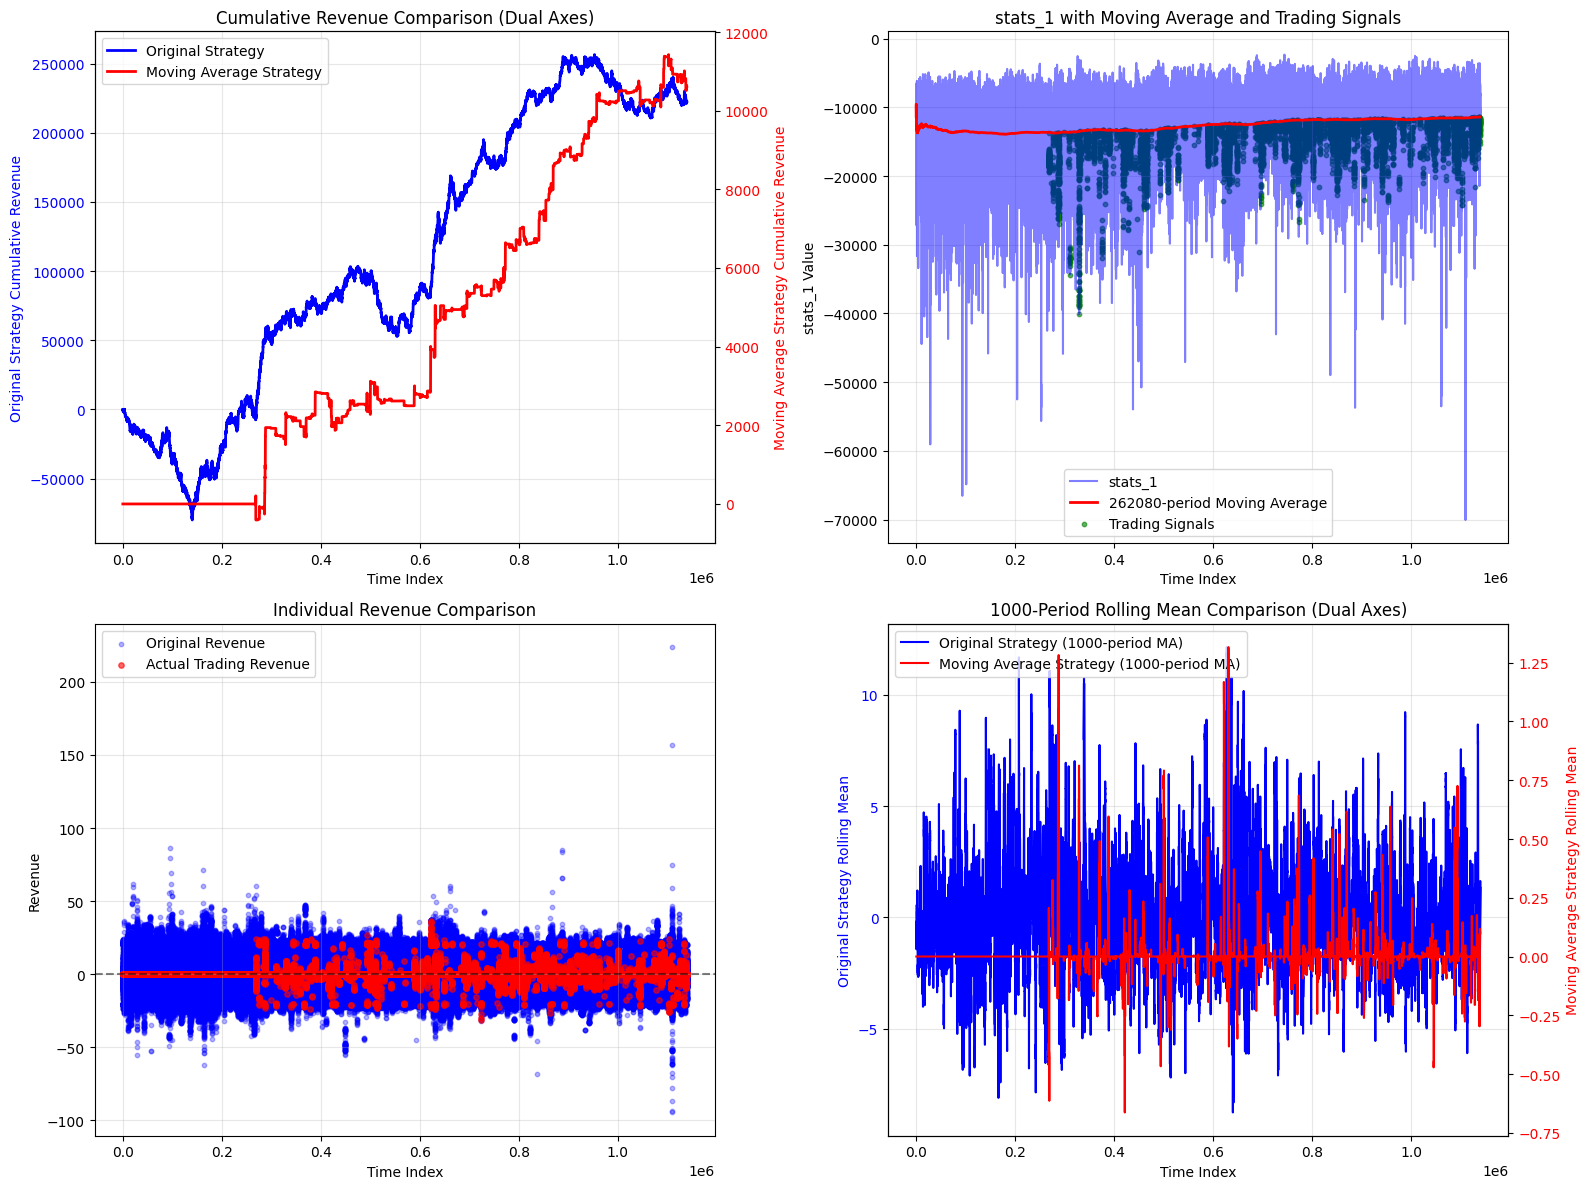


=== Strategy Performance Comparison ===
Original Strategy:
  Mean Revenue: 0.195303
  Revenue Std: 9.632859
  Sharpe Ratio: 0.0203
  Win Rate: 48.88%

Moving Average Strategy (Trading periods only):
  Mean Revenue: 1.447507
  Revenue Std: 8.370689
  Sharpe Ratio: 0.1729
  Win Rate: 58.48%

Moving Average Strategy (Including non-trading periods):
  Mean Revenue: 0.009321
  Revenue Std: 0.681571
  Sharpe Ratio: 0.0137
  Win Rate: 0.38%

=== Maximum Drawdown Analysis ===
Original Strategy Max Drawdown: -80010.625952
Moving Average Strategy Max Drawdown: -978.132958

=== Segment Analysis (every 500 data points) ===
Original Strategy segment mean revenue: 97.642896
Moving Average Strategy segment mean revenue: 4.660095
Original Strategy segment win rate: 48.75%
Moving Average Strategy segment win rate: 9.48%

Results saved to results_comparison DataFrame
Contains 1139402 rows of data


In [69]:
# Calculate moving average for stats_1 and implement trading logic
window_size = 182*24*60
# stats['stats_1_MA'] = stats['stats_1'].rolling(window=window_size).mean()
alpha = 1 / (window_size + 1)  # EMA smoothing factor
stats['stats_1_MA'] = stats['stats_1'].ewm(alpha=alpha).mean()


# Initialize actual trading revenue list
actual_trading_revenues = []

# Iterate through data, starting after moving average calculation is complete
for i in range(len(stats)):
    if i < window_size:
        # No moving average for first 20000 rows, no trading
        actual_trading_revenues.append(0)
    else:
        # Current stats_1 value
        current_stats_1 = stats['stats_1'].iloc[i]
        # Previous period moving average
        previous_ma = stats['stats_1_MA'].iloc[i-1]
        # previous_ma = 2*previous_ma+10000

    

    # (stats['stats_1'] < -10000) &
        
        # Trading condition: current stats_1 less than previous moving average

        ratio = -previous_ma/10000
        if current_stats_1 < previous_ma and stats['stats_6'].iloc[i] > 0.1 and stats['stats_5'].iloc[i] > 0.6 and stats['stats_9'].iloc[i] < 6*ratio and (abs(stats['stats_8'].iloc[i]) < 10*ratio) and (abs(stats['stats_8'].iloc[i]) > 5*ratio) :
            # Execute trade, record revenue
            actual_trading_revenues.append(stats['revenues'].iloc[i])
        else:
            # No trade, revenue = 0
            actual_trading_revenues.append(0)

# Convert to pandas Series for easier calculation
actual_trading_revenues = pd.Series(actual_trading_revenues, index=stats.index)

# Calculate cumulative returns
cumulative_original = stats['revenues'].cumsum()
cumulative_actual_trading = actual_trading_revenues.cumsum()

# Print trading statistics
trading_signals = (actual_trading_revenues != 0).sum()
total_periods = len(stats) - window_size  # Exclude first 20000 rows
signal_rate = trading_signals / total_periods if total_periods > 0 else 0

print("=== Trading Signal Analysis ===")
print(f"Total data points: {len(stats)}")
print(f"Tradable periods: {total_periods}")
print(f"Actual trades executed: {trading_signals}")
print(f"Trading signal rate: {signal_rate:.2%}")
print(f"Original total revenue: {stats['revenues'].sum():.6f}")
print(f"Actual trading total revenue: {actual_trading_revenues.sum():.6f}")
print(f"Revenue retention rate: {actual_trading_revenues.sum() / stats['revenues'].sum():.2%}")

# Create comparison charts with dual axes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Cumulative return comparison with dual axes
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

line1 = ax1.plot(cumulative_original.index, cumulative_original.values, 
                 label='Original Strategy', color='blue', linewidth=2)
line2 = ax1_twin.plot(cumulative_actual_trading.index, cumulative_actual_trading.values, 
                      label='Moving Average Strategy', color='red', linewidth=2)

ax1.set_xlabel('Time Index')
ax1.set_ylabel('Original Strategy Cumulative Revenue', color='blue')
ax1_twin.set_ylabel('Moving Average Strategy Cumulative Revenue', color='red')
ax1.set_title('Cumulative Revenue Comparison (Dual Axes)')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3)

# Chart 2: stats_1 with moving average
axes[0, 1].plot(stats['stats_1'].index, stats['stats_1'].values, 
                label='stats_1', color='blue', alpha=0.5)
axes[0, 1].plot(stats['stats_1_MA'].index, stats['stats_1_MA'].values, 
                label=f'{window_size}-period Moving Average', color='red', linewidth=2)
# Mark trading signal points
trading_points = stats.index[actual_trading_revenues != 0]
if len(trading_points) > 0:
    axes[0, 1].scatter(trading_points, stats['stats_1'].iloc[trading_points], 
                       color='green', s=10, alpha=0.6, label='Trading Signals')
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('stats_1 Value')
axes[0, 1].set_title('stats_1 with Moving Average and Trading Signals')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Individual revenue scatter plot
axes[1, 0].scatter(range(len(stats)), stats['revenues'], 
                   c='blue', alpha=0.3, s=10, label='Original Revenue')
axes[1, 0].scatter(range(len(stats)), actual_trading_revenues, 
                   c='red', alpha=0.6, s=15, label='Actual Trading Revenue')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Revenue')
axes[1, 0].set_title('Individual Revenue Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Rolling revenue comparison with dual axes
rolling_window = 1000
rolling_original = stats['revenues'].rolling(rolling_window).mean()
rolling_actual = actual_trading_revenues.rolling(rolling_window).mean()

ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

line3 = ax4.plot(rolling_original.index, rolling_original.values, 
                 label=f'Original Strategy ({rolling_window}-period MA)', color='blue')
line4 = ax4_twin.plot(rolling_actual.index, rolling_actual.values, 
                      label=f'Moving Average Strategy ({rolling_window}-period MA)', color='red')

ax4.set_xlabel('Time Index')
ax4.set_ylabel('Original Strategy Rolling Mean', color='blue')
ax4_twin.set_ylabel('Moving Average Strategy Rolling Mean', color='red')
ax4.set_title(f'{rolling_window}-Period Rolling Mean Comparison (Dual Axes)')
ax4.tick_params(axis='y', labelcolor='blue')
ax4_twin.tick_params(axis='y', labelcolor='red')

# Combine legends
lines3, labels3 = ax4.get_legend_handles_labels()
lines4, labels4 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines3 + lines4, labels3 + labels4, loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed performance analysis
print("\n=== Strategy Performance Comparison ===")

# Original strategy statistics
orig_mean = stats['revenues'].mean()
orig_std = stats['revenues'].std()
orig_sharpe = orig_mean / orig_std if orig_std != 0 else 0
orig_winrate = (stats['revenues'] > 0).mean()

print("Original Strategy:")
print(f"  Mean Revenue: {orig_mean:.6f}")
print(f"  Revenue Std: {orig_std:.6f}")
print(f"  Sharpe Ratio: {orig_sharpe:.4f}")
print(f"  Win Rate: {orig_winrate:.2%}")

# Moving average trading strategy statistics (non-zero revenues only)
actual_nonzero = actual_trading_revenues[actual_trading_revenues != 0]
if len(actual_nonzero) > 0:
    actual_mean_nonzero = actual_nonzero.mean()
    actual_std_nonzero = actual_nonzero.std()
    actual_sharpe_nonzero = actual_mean_nonzero / actual_std_nonzero if actual_std_nonzero != 0 else 0
    actual_winrate_nonzero = (actual_nonzero > 0).mean()
    
    print("\nMoving Average Strategy (Trading periods only):")
    print(f"  Mean Revenue: {actual_mean_nonzero:.6f}")
    print(f"  Revenue Std: {actual_std_nonzero:.6f}")
    print(f"  Sharpe Ratio: {actual_sharpe_nonzero:.4f}")
    print(f"  Win Rate: {actual_winrate_nonzero:.2%}")

# Moving average trading strategy statistics (including zero revenues)
actual_mean_all = actual_trading_revenues.mean()
actual_std_all = actual_trading_revenues.std()
actual_sharpe_all = actual_mean_all / actual_std_all if actual_std_all != 0 else 0
actual_winrate_all = (actual_trading_revenues > 0).mean()

print("\nMoving Average Strategy (Including non-trading periods):")
print(f"  Mean Revenue: {actual_mean_all:.6f}")
print(f"  Revenue Std: {actual_std_all:.6f}")
print(f"  Sharpe Ratio: {actual_sharpe_all:.4f}")
print(f"  Win Rate: {actual_winrate_all:.2%}")

# Maximum drawdown analysis
def calculate_max_drawdown(cumulative_returns):
    running_max = cumulative_returns.expanding().max()
    drawdown = cumulative_returns - running_max
    max_drawdown = drawdown.min()
    return max_drawdown, drawdown

orig_max_dd, orig_dd = calculate_max_drawdown(cumulative_original)
actual_max_dd, actual_dd = calculate_max_drawdown(cumulative_actual_trading)

print(f"\n=== Maximum Drawdown Analysis ===")
print(f"Original Strategy Max Drawdown: {orig_max_dd:.6f}")
print(f"Moving Average Strategy Max Drawdown: {actual_max_dd:.6f}")

# Segment analysis
chunk_size = 500
chunks_original = [stats['revenues'].iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(stats), chunk_size)]
chunks_actual = [actual_trading_revenues.iloc[i:i+chunk_size].sum() 
                for i in range(0, len(actual_trading_revenues), chunk_size)]

print(f"\n=== Segment Analysis (every {chunk_size} data points) ===")
print(f"Original Strategy segment mean revenue: {np.mean(chunks_original):.6f}")
print(f"Moving Average Strategy segment mean revenue: {np.mean(chunks_actual):.6f}")
print(f"Original Strategy segment win rate: {(np.array(chunks_original) > 0).mean():.2%}")
print(f"Moving Average Strategy segment win rate: {(np.array(chunks_actual) > 0).mean():.2%}")

# Save results
results_comparison = pd.DataFrame({
    'original_revenue': stats['revenues'],
    'actual_trading_revenue': actual_trading_revenues,
    'cumulative_original': cumulative_original,
    'cumulative_actual_trading': cumulative_actual_trading,
    'stats_1': stats['stats_1'],
    'stats_1_MA': stats['stats_1_MA'],
    'trading_signal': actual_trading_revenues != 0
})

print(f"\nResults saved to results_comparison DataFrame")
print(f"Contains {len(results_comparison)} rows of data")

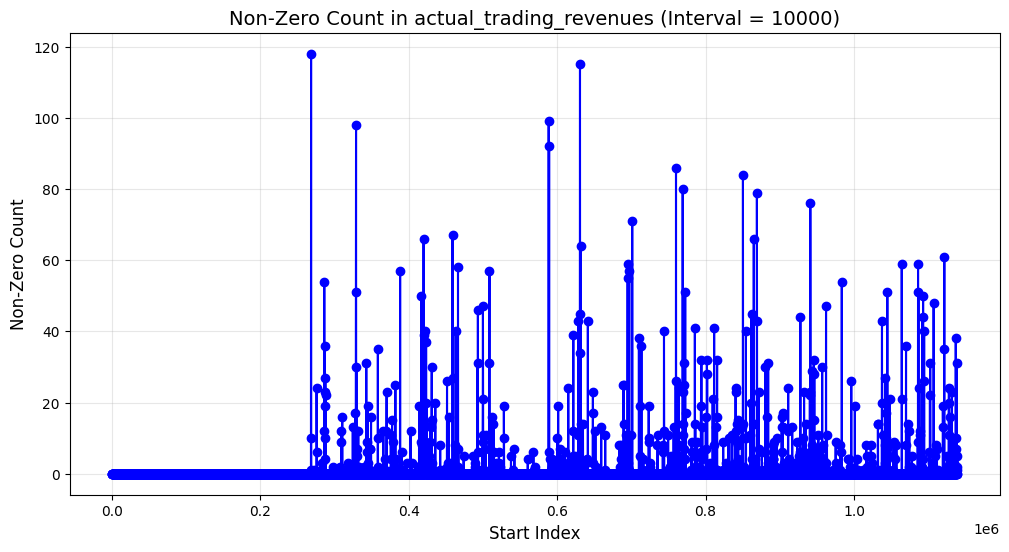

In [70]:
# 统计每隔 10000 个数据中不等于 0 的个数
interval = 200
non_zero_counts = [
  (i, (actual_trading_revenues.iloc[i:i+interval] != 0).sum())
  for i in range(0, len(actual_trading_revenues), interval)
]

# 转换为 DataFrame 以便绘图
non_zero_counts_df = pd.DataFrame(non_zero_counts, columns=['Start_Index', 'Non_Zero_Count'])

# 绘制统计结果
plt.figure(figsize=(12, 6))
plt.plot(non_zero_counts_df['Start_Index'], non_zero_counts_df['Non_Zero_Count'], marker='o', linestyle='-', color='blue')
plt.title('Non-Zero Count in actual_trading_revenues (Interval = 10000)', fontsize=14)
plt.xlabel('Start Index', fontsize=12)
plt.ylabel('Non-Zero Count', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_5032/2914648819.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time_index = pd.date_range(start='2023-01-01', periods=len(actual_trading_revenues), freq='T')


=== Daily Revenue Analysis ===
Total days: 792
Non-zero days: 306
Non-zero ratio: 38.64%

Non-zero daily revenue distribution:
count     306.000000
mean       34.707050
std       198.836063
min      -642.438662
25%       -29.836216
50%         1.536020
75%        40.796602
max      1471.766878
dtype: float64


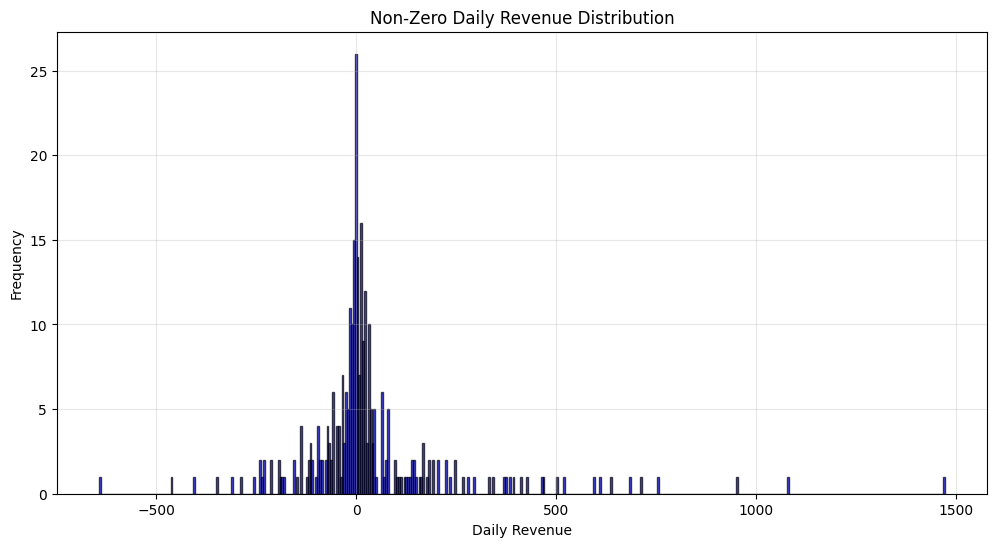

In [71]:
# 假设数据是按分钟频率的，转换为天间隔求和
# 创建一个时间索引（如果没有时间索引，可以根据数据长度生成）
time_index = pd.date_range(start='2023-01-01', periods=len(actual_trading_revenues), freq='T')
actual_trading_revenues.index = time_index

# 按天间隔求和
daily_revenues = actual_trading_revenues.resample('D').sum()

# 统计非零比例
non_zero_ratio = (daily_revenues != 0).mean()

# 输出非零分布
non_zero_distribution = daily_revenues[daily_revenues != 0]

# 打印结果
print("=== Daily Revenue Analysis ===")
print(f"Total days: {len(daily_revenues)}")
print(f"Non-zero days: {len(non_zero_distribution)}")
print(f"Non-zero ratio: {non_zero_ratio:.2%}")
print("\nNon-zero daily revenue distribution:")
print(non_zero_distribution.describe())

# 可视化非零分布
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(non_zero_distribution, bins=450, alpha=0.7, color='blue', edgecolor='black')
plt.title('Non-Zero Daily Revenue Distribution')
plt.xlabel('Daily Revenue')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

=== Trading Revenues Processing Statistics ===
Total windows processed: 5698
Window size: 200
Keep count per window: 40
Original non-zero count: 7337
Kept non-zero count: 6362
Non-zero reduction ratio: 13.29%
Non-zero retention ratio: 86.71%
Original total revenue: 10620.357353
Processed total revenue: 9371.634874
Revenue retention ratio: 88.24%


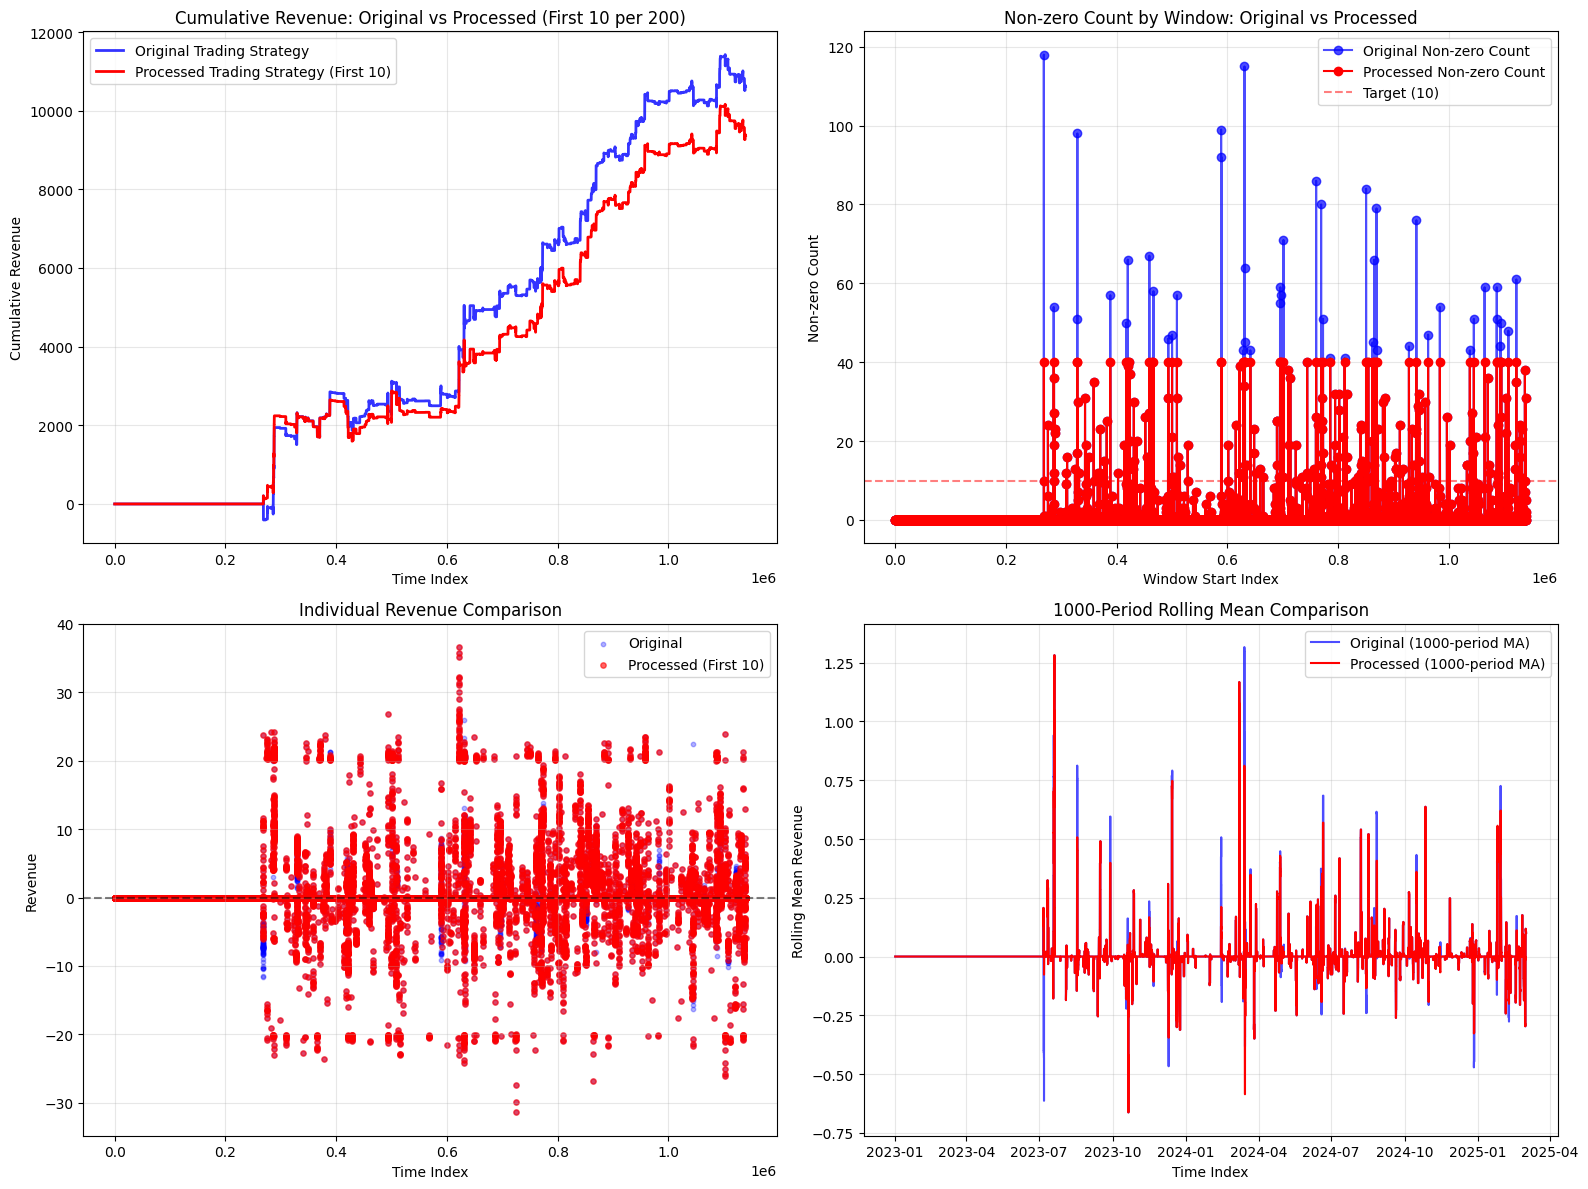


=== Performance Metrics Comparison ===
Original Trading Strategy:
  Mean Revenue: 0.009321
  Revenue Std: 0.681571
  Sharpe Ratio: 0.0137
  Win Rate: 0.38%

Processed Trading Strategy (First 10 per 200):
  Mean Revenue: 0.008225
  Revenue Std: 0.654465
  Sharpe Ratio: 0.0126
  Win Rate: 0.32%

Processed Strategy (Non-zero trades only):
  Mean Revenue: 1.473064
  Revenue Std: 8.635072
  Sharpe Ratio: 0.1706
  Win Rate: 58.20%


In [72]:
# 对actual_trading_revenues进一步处理：每相邻200个只取前10个非0值
import numpy as np
import pandas as pd

def process_trading_revenues_first_n(revenues, window_size=200, keep_count=10):
    """
    对trading revenues进行处理
    在每个window_size的窗口中，只保留前keep_count个非零值
    
    Parameters:
    revenues: pd.Series, 原始的trading revenues
    window_size: int, 窗口大小，默认200
    keep_count: int, 每个窗口保留的前N个非零值数量，默认10
    
    Returns:
    processed_revenues: pd.Series, 处理后的revenues
    processing_stats: dict, 处理统计信息
    """
    processed_revenues = revenues.copy()
    
    total_original_nonzero = 0
    total_kept_nonzero = 0
    total_windows = 0
    
    # 按窗口处理
    for start_idx in range(0, len(revenues), window_size):
        end_idx = min(start_idx + window_size, len(revenues))
        window_data = revenues.iloc[start_idx:end_idx]
        
        # 找到窗口内非零值的索引（按顺序）
        nonzero_indices = window_data[window_data != 0].index.tolist()
        original_nonzero_count = len(nonzero_indices)
        
        total_original_nonzero += original_nonzero_count
        total_windows += 1
        
        # 如果非零值数量超过keep_count，只保留前keep_count个
        if len(nonzero_indices) > keep_count:
            # 保留前keep_count个索引
            keep_indices = nonzero_indices[:keep_count]
            
            # 将超出keep_count的非零值设为0
            for idx in nonzero_indices[keep_count:]:
                processed_revenues.iloc[processed_revenues.index.get_loc(idx)] = 0
            
            kept_count = keep_count
        else:
            # 如果非零值数量不超过keep_count，全部保留
            kept_count = len(nonzero_indices)
        
        total_kept_nonzero += kept_count
    
    # 统计处理结果
    processing_stats = {
        'total_windows': total_windows,
        'window_size': window_size,
        'keep_count_per_window': keep_count,
        'original_nonzero_total': total_original_nonzero,
        'kept_nonzero_total': total_kept_nonzero,
        'reduction_ratio': 1 - (total_kept_nonzero / total_original_nonzero) if total_original_nonzero > 0 else 0,
        'retention_ratio': total_kept_nonzero / total_original_nonzero if total_original_nonzero > 0 else 0,
        'original_total_revenue': revenues.sum(),
        'processed_total_revenue': processed_revenues.sum(),
        'revenue_retention_ratio': processed_revenues.sum() / revenues.sum() if revenues.sum() != 0 else 0
    }
    
    return processed_revenues, processing_stats

# 应用处理函数
processed_trading_revenues, stats_info = process_trading_revenues_first_n(
    actual_trading_revenues, 
    window_size=200, 
    keep_count=40
)

# 打印处理统计信息
print("=== Trading Revenues Processing Statistics ===")
print(f"Total windows processed: {stats_info['total_windows']}")
print(f"Window size: {stats_info['window_size']}")
print(f"Keep count per window: {stats_info['keep_count_per_window']}")
print(f"Original non-zero count: {stats_info['original_nonzero_total']}")
print(f"Kept non-zero count: {stats_info['kept_nonzero_total']}")
print(f"Non-zero reduction ratio: {stats_info['reduction_ratio']:.2%}")
print(f"Non-zero retention ratio: {stats_info['retention_ratio']:.2%}")
print(f"Original total revenue: {stats_info['original_total_revenue']:.6f}")
print(f"Processed total revenue: {stats_info['processed_total_revenue']:.6f}")
print(f"Revenue retention ratio: {stats_info['revenue_retention_ratio']:.2%}")

# 计算累积收益
cumulative_processed = processed_trading_revenues.cumsum()

# 创建对比图表
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图1：累积收益对比
axes[0, 0].plot(cumulative_actual_trading.values, 
                label='Original Trading Strategy', color='blue', linewidth=2, alpha=0.8)
axes[0, 0].plot(cumulative_processed.values, 
                label='Processed Trading Strategy (First 10)', color='red', linewidth=2)
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Cumulative Revenue')
axes[0, 0].set_title('Cumulative Revenue: Original vs Processed (First 10 per 200)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 图2：每个窗口的非零计数对比
window_comparisons = []
for start_idx in range(0, len(actual_trading_revenues), 200):
    end_idx = min(start_idx + 200, len(actual_trading_revenues))
    
    original_nonzero = (actual_trading_revenues.iloc[start_idx:end_idx] != 0).sum()
    processed_nonzero = (processed_trading_revenues.iloc[start_idx:end_idx] != 0).sum()
    
    window_comparisons.append({
        'window_start': start_idx,
        'original_nonzero': original_nonzero,
        'processed_nonzero': processed_nonzero
    })

window_df = pd.DataFrame(window_comparisons)

axes[0, 1].plot(window_df['window_start'], window_df['original_nonzero'], 
                'o-', label='Original Non-zero Count', color='blue', alpha=0.7)
axes[0, 1].plot(window_df['window_start'], window_df['processed_nonzero'], 
                'o-', label='Processed Non-zero Count', color='red')
axes[0, 1].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Target (10)')
axes[0, 1].set_xlabel('Window Start Index')
axes[0, 1].set_ylabel('Non-zero Count')
axes[0, 1].set_title('Non-zero Count by Window: Original vs Processed')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 图3：个别收益散点图
axes[1, 0].scatter(range(len(actual_trading_revenues)), actual_trading_revenues, 
                   c='blue', alpha=0.3, s=10, label='Original')
axes[1, 0].scatter(range(len(processed_trading_revenues)), processed_trading_revenues, 
                   c='red', alpha=0.6, s=15, label='Processed (First 10)')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Revenue')
axes[1, 0].set_title('Individual Revenue Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 图4：滚动平均对比
rolling_window = 1000
rolling_original = actual_trading_revenues.rolling(rolling_window).mean()
rolling_processed = processed_trading_revenues.rolling(rolling_window).mean()

axes[1, 1].plot(rolling_original.index, rolling_original.values, 
                label=f'Original ({rolling_window}-period MA)', color='blue', alpha=0.7)
axes[1, 1].plot(rolling_processed.index, rolling_processed.values, 
                label=f'Processed ({rolling_window}-period MA)', color='red')
axes[1, 1].set_xlabel('Time Index')
axes[1, 1].set_ylabel('Rolling Mean Revenue')
axes[1, 1].set_title(f'{rolling_window}-Period Rolling Mean Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 详细性能分析
print("\n=== Performance Metrics Comparison ===")

# 原策略统计
orig_mean = actual_trading_revenues.mean()
orig_std = actual_trading_revenues.std()
orig_sharpe = orig_mean / orig_std if orig_std != 0 else 0
orig_winrate = (actual_trading_revenues > 0).mean()

print("Original Trading Strategy:")
print(f"  Mean Revenue: {orig_mean:.6f}")
print(f"  Revenue Std: {orig_std:.6f}")
print(f"  Sharpe Ratio: {orig_sharpe:.4f}")
print(f"  Win Rate: {orig_winrate:.2%}")

# 处理后策略统计
proc_mean = processed_trading_revenues.mean()
proc_std = processed_trading_revenues.std()
proc_sharpe = proc_mean / proc_std if proc_std != 0 else 0
proc_winrate = (processed_trading_revenues > 0).mean()

print("\nProcessed Trading Strategy (First 10 per 200):")
print(f"  Mean Revenue: {proc_mean:.6f}")
print(f"  Revenue Std: {proc_std:.6f}")
print(f"  Sharpe Ratio: {proc_sharpe:.4f}")
print(f"  Win Rate: {proc_winrate:.2%}")

# 只考虑非零交易的统计
proc_nonzero = processed_trading_revenues[processed_trading_revenues != 0]
if len(proc_nonzero) > 0:
    proc_nz_mean = proc_nonzero.mean()
    proc_nz_std = proc_nonzero.std()
    proc_nz_sharpe = proc_nz_mean / proc_nz_std if proc_nz_std != 0 else 0
    proc_nz_winrate = (proc_nonzero > 0).mean()
    
    print("\nProcessed Strategy (Non-zero trades only):")
    print(f"  Mean Revenue: {proc_nz_mean:.6f}")
    print(f"  Revenue Std: {proc_nz_std:.6f}")
    print(f"  Sharpe Ratio: {proc_nz_sharpe:.4f}")
    print(f"  Win Rate: {proc_nz_winrate:.2%}")

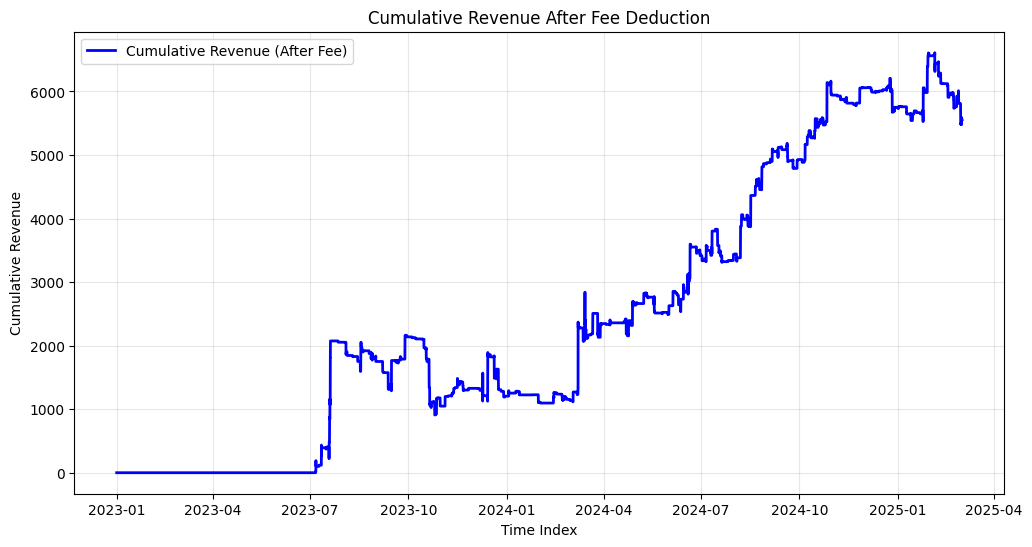

In [73]:
# 对非零项减去手续费
processed_trading_revenues_after_fee = processed_trading_revenues.copy()
processed_trading_revenues_after_fee[processed_trading_revenues_after_fee != 0] -= 0.6

# 计算累计收益
cumulative_revenues_after_fee = processed_trading_revenues_after_fee.cumsum()

# 绘制累计收益图
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenues_after_fee.index, cumulative_revenues_after_fee.values, label='Cumulative Revenue (After Fee)', color='blue', linewidth=2)
plt.title('Cumulative Revenue After Fee Deduction')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [74]:
# # Modified signal count analysis
# window = 200
# signal_counts = pd.Series(np.zeros(len(stats)), index=stats.index)
# for i in range(len(stats)):
#     if i >= window:
#         signal_counts[i] = condition_mask[i-window:i].sum()
#     else:
#         signal_counts[i] = condition_mask[:i].sum()

# # Create plot with dual y-axes
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# # Plot 1: Cumulative Revenue with Signal Count
# ax1.plot(cumulative_original.index, cumulative_original.values, 
#          label='Original', color='blue', alpha=0.7, linewidth=2)
# ax1.plot(cumulative_filtered.index, cumulative_filtered.values, 
#          label='Filtered', color='red', linewidth=2)
# ax1.set_xlabel('Time Index')
# ax1.set_ylabel('Cumulative Revenue')
# ax1.set_title('Cumulative Revenue and Position Count')
# ax1.legend(loc='upper left')
# ax1.grid(True, alpha=0.3)

# # Add position count on secondary y-axis
# ax12 = ax1.twinx()
# ax12.fill_between(signal_counts.index, signal_counts.values, alpha=0.2, color='green')
# ax12.plot(signal_counts.index, signal_counts.values, color='green', alpha=0.6, 
#           label=f'Signal Count ({window}-period)')
# ax12.set_ylabel('Number of Active Signals', color='green')
# ax12.tick_params(axis='y', labelcolor='green')
# ax12.legend(loc='upper right')

# # Plot 2: Signal Count vs Revenue with Enhanced Analysis
# ax2.scatter(signal_counts, filtered_revenues, alpha=0.5, c='blue')
# ax2.set_xlabel(f'Number of Active Signals (in {window}-period window)')
# ax2.set_ylabel('Revenue')
# ax2.set_title('Revenue vs Active Signal Count')
# ax2.grid(True, alpha=0.3)

# # Add trend line
# z = np.polyfit(signal_counts, filtered_revenues, 1)
# p = np.poly1d(z)
# ax2.plot(signal_counts, p(signal_counts), "r--", alpha=0.8, 
#          label=f'Trend (slope: {z[0]:.4f})')
# ax2.legend()

# plt.tight_layout()
# plt.show()

# # Print basic statistics
# print(f"\n=== Signal Count Analysis ({window}-period window) ===")
# print(f"Average signals active: {signal_counts.mean():.2f}")
# print(f"Max signals active: {signal_counts.max():.0f}")
# print(f"Min signals active: {signal_counts.min():.0f}")
# print(f"Median signals active: {signal_counts.median():.2f}")

# # Modified quantile analysis to handle duplicates
# # Create custom bins based on signal distribution
# signal_bins = pd.qcut(signal_counts, q=80, duplicates='drop')
# revenue_by_signals = pd.DataFrame({
#     'signal_count': signal_counts,
#     'revenue': filtered_revenues,
#     'bin': signal_bins
# })
# # 只保留 revenue ≠ 0 的记录
# revenue_nonzero = revenue_by_signals[revenue_by_signals['revenue'] != 0]

# # 按 bin 分组统计
# stats_by_bin = revenue_nonzero.groupby('bin').agg({
#     'signal_count': ['min', 'max', 'mean', 'count'],
#     'revenue': [
#         'mean', 
#         'std', 
#         ('pos_ratio', lambda x: (x > 0).mean())  # 自定义命名: 正收益比例
#     ]
# }).round(4)

# # 整理列名
# stats_by_bin.columns = ['_'.join(col).strip() for col in stats_by_bin.columns.values]

# print(stats_by_bin)

# # Additional analysis of extreme cases
# high_signal_periods = revenue_by_signals[revenue_by_signals['signal_count'] > signal_counts.quantile(0.9)]
# print("\nHigh Signal Periods Analysis (top 10%):")
# print(f"Number of periods: {len(high_signal_periods)}")
# print(f"Average revenue: {high_signal_periods['revenue'].mean():.4f}")
# print(f"Win rate: {(high_signal_periods['revenue'] > 0).mean():.2%}")

In [75]:
# random_seed = 42
# np.random.seed(random_seed)
# train_frac = 0.6
# size = len(stats)
# train_size = int(size * train_frac)
# shuffled_indices = np.random.permutation(size)
# train_indices = shuffled_indices[:train_size]
# test_indices = shuffled_indices[train_size:]
# train_set = stats.iloc[train_indices]
# test_set = stats.iloc[test_indices]

train_set = stats[:int(0.6*len(stats))]
test_set = stats[int(0.6*len(stats)):]

In [76]:
train_means = train_set.mean()
test_means = test_set.mean()


In [77]:
train_means

stats_1       -12898.182966
stats_2           31.368570
stats_3            0.029866
stats_4       773983.204046
stats_5            0.574028
stats_6            0.020380
stats_7            0.592010
stats_8            0.220374
stats_9            5.139234
stats_10      156015.788899
revenues           0.226131
stats_1_MA    -13235.474560
dtype: float64

In [78]:
test_means

stats_1      -1.119960e+04
stats_2       3.105582e+01
stats_3       2.964446e-01
stats_4       1.347521e+06
stats_5       6.334079e-01
stats_6       2.492754e-02
stats_7       7.178738e-01
stats_8       2.525593e-02
stats_9       4.297854e+00
stats_10      5.063416e+04
revenues      1.490602e-01
stats_1_MA   -1.176358e+04
dtype: float64

In [79]:
train_set.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues', 'stats_1_MA'],
      dtype='object')